# 02 - Model Experiments

- Version 1.01  
- updated 30.04.26  

Pending:  
- adding Hyperopt tuning for classical models  

Runs all models against the same dataset and logs results to MLflow.
All preprocessing imported from 01_preprocessing.ipynb via %run.

| Notebook | Purpose |
|----------|---------|
| 00_EDA | Explore dataset |
| 01_preprocessing | Prepare model variants |
| 02_experiments | Train, evaluate, compare (here) |

## Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import mlflow
import mlflow.xgboost
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import sys
sys.path.append(r'Q:\scripts\projects\ts-model-framework')
import config

mlflow.set_tracking_uri(config.MLFLOW_URI)
mlflow.set_experiment(config.EXPERIMENT)

import warnings
warnings.filterwarnings('ignore')

print(f"Project path: {config.PROJECT_PATH}")
print(f"Data path: {config.DATA_PATH}")
print(f"Data path: {config.EXPORTS_PATH}")

print("Libraries loaded.")
print(f"MLflow tracking: {config.EXPERIMENT}")

Project path: Q:\scripts\projects\ts-model-framework
Data path: Q:\scripts\projects\ts-model-framework\data
Data path: Q:\scripts\projects\ts-model-framework\exports
Libraries loaded.
MLflow tracking: ts-model-framework


---
## S1 - Load Preprocessed Data
Runs 01_preprocessing.ipynb and inherits all prepared datasets.

In [2]:
# %run {os.getenv('PREPROCESSING_SCRIPT')}

In [4]:
%run Q:/scripts/projects/ts-model-framework/exports/01_preprocessing.py

Project path: Q:\scripts\projects\ts-model-framework
Data path: Q:\scripts\projects\ts-model-framework\data
Data path: Q:\scripts\projects\ts-model-framework\exports
Libraries loaded.
Missing dates found: 2
Missing dates filled with zeros.
Core dataset loaded: (454, 24)
Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Train: (364, 24) | 2013-01-02 00:00:00 to 2013-12-31 00:00:00
Test:  (90, 24)  | 2014-01-01 00:00:00 to 2014-03-31 00:00:00
XGBoost train: (364, 23) | test: (90, 23)
SARIMAX train: (364,) | test: (90,)
Exog columns: ['dcoilwtico', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday']
Prophet train: (364, 2) | test: (90, 2)
          ds      y
0 2013-01-02  582.0
1 2013-01-03  310.0
2 2013-01-04  338.0
LSTM train shape: (334, 30, 1) | test shape: (60, 30, 1)
Scaler range: 0.00 to 1090.00


---
## S2 - Shared Evaluation Function
Single function used by ALL models for consistent metric calculation.

In [6]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    bias = np.mean(y_pred - y_true)

    print(f"\n{model_name}")
    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")

    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}

---
## S3 - XGBoost Baseline
No hyperparameter tuning -- default parameters only.
Goal: establish a reproducible baseline before any optimization.

In [7]:
xgb_params = {
    "n_estimators": 1000,
    "early_stopping_rounds": 50
}

with mlflow.start_run(run_name="xgboost-baseline"):
    model_xgb = xgb.XGBRegressor(**xgb_params)
    model_xgb.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)

    preds_xgb = model_xgb.predict(X_test)
    metrics   = evaluate(y_test, preds_xgb, "XGBoost Baseline")
    metrics_xgb = evaluate(y_test, preds_xgb, "XGBoost Baseline")
    mlflow.log_params(xgb_params)
    mlflow.log_metrics(metrics)
    mlflow.xgboost.log_model(model_xgb, "model")

2026/04/30 18:53:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost Baseline
  RMSE: 144.45 | MAE: 100.50 | MAPE: inf% | R²: 0.4241

XGBoost Baseline
  RMSE: 144.45 | MAE: 100.50 | MAPE: inf% | R²: 0.4241
🏃 View run xgboost-baseline at: http://localhost:5000/#/experiments/2/runs/09bba5cf22f946a697cb15c8b2aa6e56
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S4 - SARIMAX Baseline

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_order        = (1, 0, 1)
sarimax_seasonal     = (1, 0, 0, 7)

with mlflow.start_run(run_name="sarimax-baseline"):
    model_sarimax = SARIMAX(
        y_sarimax_train,
        exog=exog_train,
        order=sarimax_order,
        seasonal_order=sarimax_seasonal
    ).fit(disp=False)

    preds_sarimax = model_sarimax.forecast(
        steps=len(y_sarimax_test),
        exog=exog_test
    )
    metrics = evaluate(y_sarimax_test.values, preds_sarimax.values, "SARIMAX Baseline")
    metrics_sarimax = evaluate(y_sarimax_test.values, preds_sarimax.values, "SARIMAX Baseline")

    mlflow.log_params({"order": str(sarimax_order), "seasonal_order": str(sarimax_seasonal)})
    mlflow.log_metrics(metrics)


SARIMAX Baseline
  RMSE: 185.90 | MAE: 142.98 | MAPE: inf% | R²: 0.0462

SARIMAX Baseline
  RMSE: 185.90 | MAE: 142.98 | MAPE: inf% | R²: 0.0462
🏃 View run sarimax-baseline at: http://localhost:5000/#/experiments/2/runs/46b261f0e1c74c4ea5febd49ac7a2cad
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S5 - Prophet Baseline

In [9]:
from prophet import Prophet

with mlflow.start_run(run_name="prophet-baseline"):
    model_prophet = Prophet()
    model_prophet.fit(prophet_train)

    future   = model_prophet.make_future_dataframe(periods=len(prophet_test))
    forecast  = model_prophet.predict(future)
    preds_prophet = forecast['yhat'].tail(len(prophet_test)).values

    metrics = evaluate(prophet_test['y'].values, preds_prophet, "Prophet Baseline")
    metrics_prophet = evaluate(prophet_test['y'].values, preds_prophet, "Prophet Baseline")
    
    mlflow.log_params({"model": "prophet-basic"})
    mlflow.log_metrics(metrics)

Importing plotly failed. Interactive plots will not work.
18:53:58 - cmdstanpy - INFO - Chain [1] start processing
18:53:58 - cmdstanpy - INFO - Chain [1] done processing



Prophet Baseline
  RMSE: 150.47 | MAE: 98.36 | MAPE: inf% | R²: 0.3751

Prophet Baseline
  RMSE: 150.47 | MAE: 98.36 | MAPE: inf% | R²: 0.3751
🏃 View run prophet-baseline at: http://localhost:5000/#/experiments/2/runs/90de7f92039446729b66d4e883890054
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S6 - Results Summary
Compares all logged runs from this experiment in a single table.

In [10]:
runs = mlflow.search_runs(experiment_names=["ts-model-framework"])

summary = runs[["tags.mlflow.runName", "metrics.rmse", "metrics.mae", 
                "metrics.mape", "metrics.r2"]].rename(
    columns={"tags.mlflow.runName": "model"}
).sort_values("metrics.rmse")

print(summary.to_string(index=False))

           model  metrics.rmse  metrics.mae  metrics.mape  metrics.r2
      lstm-tuned    106.429920    80.201124  2.048424e+01    0.524849
      lstm-tuned    107.265947    81.288401  2.059099e+01    0.517355
       rnn-tuned    108.670625    82.143942  2.163120e+01    0.504632
    rnn-baseline    108.750699    85.475664  2.259691e+01    0.503901
    rnn-baseline    108.750699    85.475664  2.259691e+01    0.503901
       rnn-tuned    109.697767    85.677690  2.223141e+01    0.495223
   lstm-baseline    127.093375   104.573866  2.838743e+01    0.322437
xgboost-baseline    144.447188   100.504604 1.797693e+308    0.424109
xgboost-baseline    144.447188   100.504604 1.797693e+308    0.424109
xgboost-baseline    144.447188   100.504604 1.797693e+308    0.424109
xgboost-baseline    144.447188   100.504604 1.797693e+308    0.424109
xgboost-baseline    146.676333   102.652565  2.364605e+01    0.367522
xgboost-baseline    146.676333   102.652565  2.364605e+01    0.367522
prophet-baseline    

---
## S7 - Visual Comparison

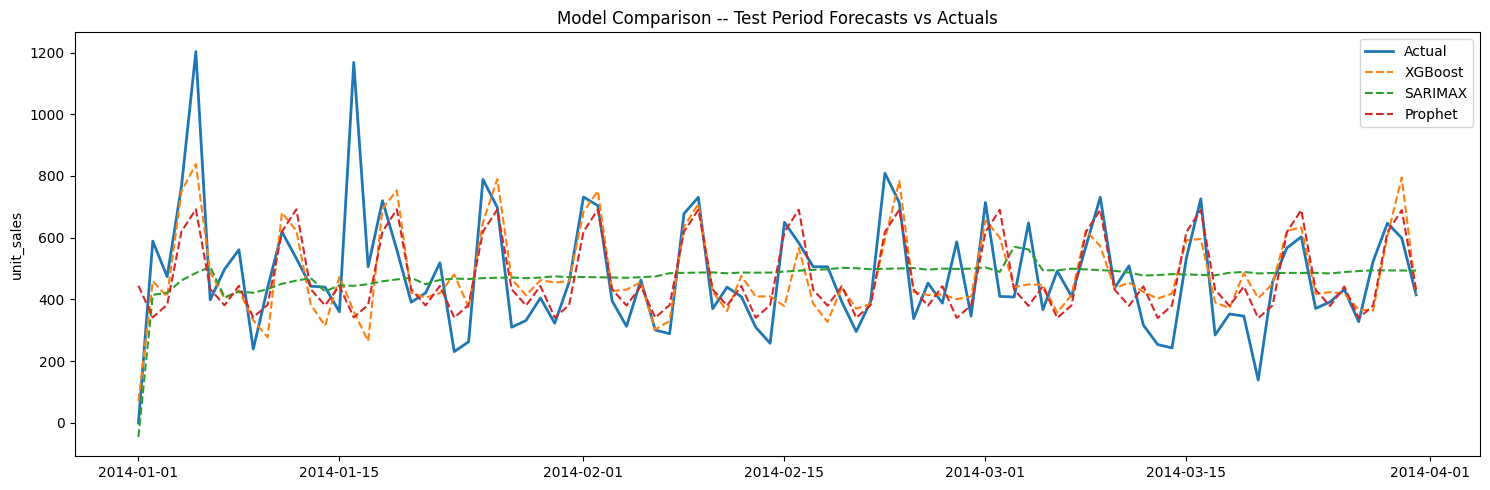

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(y_test.index, y_test.values, label='Actual', linewidth=2)
ax.plot(y_test.index, preds_xgb, label='XGBoost', linestyle='--')
ax.plot(y_sarimax_test.index, preds_sarimax, label='SARIMAX', linestyle='--')
ax.plot(prophet_test['ds'].values[-len(preds_prophet):], 
        preds_prophet, label='Prophet', linestyle='--')

ax.set_title('Model Comparison -- Test Period Forecasts vs Actuals')
ax.set_ylabel(config.TARGET_COLUMN)
ax.legend()
plt.tight_layout()
plt.show()

---  

## S8 -  Save Best Model

In [13]:
# Saves the best model from Classical + XGBoost only

# Collect all model results
model_objects = {
    "xgboost-baseline": model_xgb,
    "sarimax-baseline": model_sarimax,
    "prophet-baseline": model_prophet,
}
# Pick best from LOCAL results only -- not MLflow
local_results = {
    "xgboost-baseline": metrics_xgb["rmse"],
    "sarimax-baseline": metrics_sarimax["rmse"],
    "prophet-baseline": metrics_prophet["rmse"],
}
best_model_name = min(local_results, key=local_results.get)
print(f"Best classical/XGBoost model: {best_model_name}")

# Save best model for Streamlit
# best_model_object = model_objects[best_model_name]
save_path = os.path.join(config.MODELS_PATH, "best_model.pkl")
joblib.dump(model_objects[best_model_name], save_path)

name_path = os.path.join(config.MODELS_PATH, "best_model_name.txt")
with open(name_path, "w") as f:
    f.write(best_model_name)

print(f"Model saved: {save_path}")
print(f"Model name saved: {name_path}")

Best classical/XGBoost model: xgboost-baseline
Model saved: Q:\scripts\projects\ts-model-framework\models\best_model.pkl
Model name saved: Q:\scripts\projects\ts-model-framework\models\best_model_name.txt


---
## S9 - Notes & Observations
Document findings per experiment run.

- Best model this run:
- Notable differences between models:
- Features that helped/hurt:
- Next experiment to try: